# Import Libraries

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

In [2]:
import numpy as np
import pandas as pd
from models.tabular.XGBoost.data import get_data
from models.tabular.XGBoost.preprocess import tts, preprocess_features
from sklearn.pipeline import make_pipeline
from flaml import AutoML
from sklearn.metrics import recall_score, accuracy_score, f1_score, precision_score
import matplotlib.pyplot as plt


# Load Data, TTS, Preprocess

In [3]:
# Step 1: Load data
df = get_data('../data')

# Step 2: Train-test split
X_train, X_test, y_train, y_test = tts(df)
preproc= make_pipeline(preprocess_features())

# Step 3: Preprocess features
X_train_prep = preproc.fit_transform(X_train)
X_test_prep = preproc.transform(X_test)


✅ Tabular data loaded and cleaned, shape: (61069, 17)


In [4]:
print(type(X_train_prep))
print(type(y_test))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


# AutoML : Machine Learning finger in the nose

## AutoML via Accuracy

In [ ]:
# This one works
automl = AutoML()

# Fit AutoML
automl.fit(
    X_train=X_train_prep,
    y_train=y_train,
    time_budget=600,
    metric='accuracy',
    task='classification',
    estimator_list=['xgboost', 'xgb_limitdepth', 'rf', 'lgbm',
                    'lrl1', 'lrl2', 'extra_tree', 'kneighbor'])

# Best estimator: xgboost
# Best hyperparameters: {'n_estimators': 573, 'max_leaves': 185, 'min_child_weight': 5.58173960038311,
# 'learning_rate': 0.026433749110111558, 'subsample': 0.9343138048340431, 'colsample_bylevel': 0.6271842665765733,
# 'colsample_bytree': 0.6127995857505711, 'reg_alpha': 0.0009765625, 'reg_lambda': 2.8116286071118224}
# Best accuracy: 0.8412438625204582

[flaml.automl.logger: 03-17 10:45:54] {1679} INFO - task = classification
[flaml.automl.logger: 03-17 10:45:54] {1690} INFO - Evaluation method: holdout
[flaml.automl.logger: 03-17 10:45:54] {1788} INFO - Minimizing error metric: 1-accuracy
[flaml.automl.logger: 03-17 10:45:54] {1900} INFO - List of ML learners in AutoML Run: ['xgboost', 'xgb_limitdepth', 'rf', 'lgbm', 'lrl1', 'lrl2', 'extra_tree', 'kneighbor']
[flaml.automl.logger: 03-17 10:45:54] {2218} INFO - iteration 0, current learner xgboost
[flaml.automl.logger: 03-17 10:45:54] {2344} INFO - Estimated sufficient time budget=1663s. Estimated necessary time budget=30s.
[flaml.automl.logger: 03-17 10:45:54] {2391} INFO -  at 1.0s,	estimator xgboost's best error=0.3713,	best estimator xgboost's best error=0.3713
[flaml.automl.logger: 03-17 10:45:54] {2218} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 03-17 10:45:54] {2391} INFO -  at 1.1s,	estimator lgbm's best error=0.4283,	best estimator xgboost's best error=0.3

In [6]:
# Predict probabilities
y_proba = automl.predict_proba(X_test_prep)[:,1]  # probability of class 1

# Threshold tuning to maximize recall
thresholds = np.arange(0.1, 0.9, 0.05)
best_thresh = 0.5
best_recall = 0

for t in thresholds:
    y_pred_t = (y_proba > t).astype(int)
    r = recall_score(y_test, y_pred_t)
    if r > best_recall:
        best_recall = r
        best_thresh = t

# 10️⃣ Final predictions
y_pred = (y_proba > best_thresh).astype(int)

# 11️⃣ Print results
print(f"Best threshold for recall: {best_thresh}")
print(f"Recall at threshold {best_thresh}: {best_recall}")
print("Best estimator:", automl.best_estimator)
print("Best hyperparameters:", automl.best_config)
best_accuracy = 1 - automl.best_loss
print("Best accuracy:", best_accuracy)

Best threshold for recall: 0.1
Recall at threshold 0.1: 0.9762664539289988
Best estimator: xgboost
Best hyperparameters: {'n_estimators': 573, 'max_leaves': 185, 'min_child_weight': 5.58173960038311, 'learning_rate': 0.026433749110111558, 'subsample': 0.9343138048340431, 'colsample_bylevel': 0.6271842665765733, 'colsample_bytree': 0.6127995857505711, 'reg_alpha': 0.0009765625, 'reg_lambda': 2.8116286071118224}
Best accuracy: 0.8412438625204582


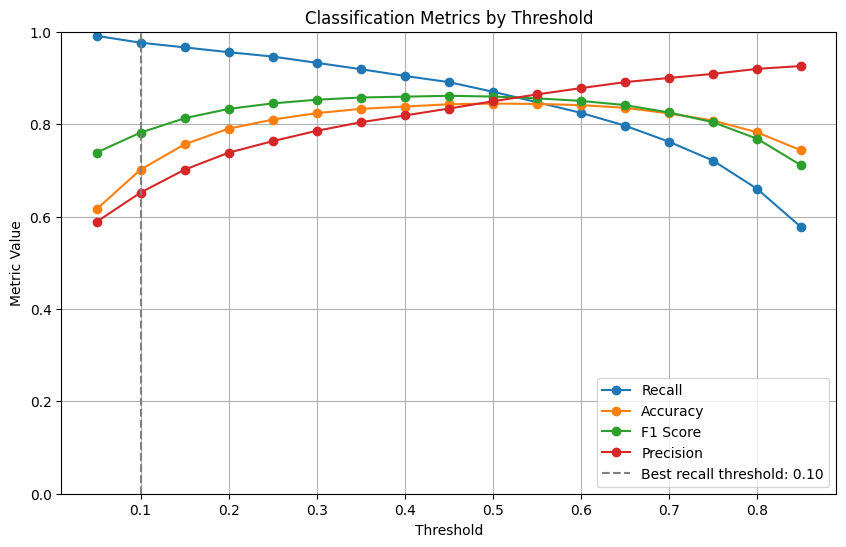

In [7]:
# Threshold range
thresholds = np.arange(0.05, 0.9, 0.05)

# Store metrics
recalls = []
accuracies = []
f1s = []
precisions = []

for t in thresholds:
    y_pred_t = (y_proba > t).astype(int)
    recalls.append(recall_score(y_test, y_pred_t))
    accuracies.append(accuracy_score(y_test, y_pred_t))
    f1s.append(f1_score(y_test, y_pred_t))
    precisions.append(precision_score(y_test, y_pred_t))

# Plot
plt.figure(figsize=(10,6))
plt.plot(thresholds, recalls, marker='o', label='Recall')
plt.plot(thresholds, accuracies, marker='o', label='Accuracy')
plt.plot(thresholds, f1s, marker='o', label='F1 Score')
plt.plot(thresholds, precisions, marker='o', label='Precision')
plt.axvline(best_thresh, color='gray', linestyle='--', label=f'Best recall threshold: {best_thresh:.2f}')
plt.title("Classification Metrics by Threshold")
plt.xlabel("Threshold")
plt.ylabel("Metric Value")
plt.ylim(0,1)
plt.grid(True)
plt.legend()
plt.show()

## AutoML via F1

In [5]:
# This one works
automl = AutoML()

# Fit AutoML
automl.fit(
    X_train=X_train_prep,
    y_train=y_train,
    time_budget=600,
    metric='f1',
    task='classification',
    estimator_list=['xgboost', 'xgb_limitdepth', 'rf', 'lgbm',
                    'lrl1', 'lrl2', 'extra_tree', 'kneighbor'])

[flaml.automl.logger: 03-17 11:00:29] {1679} INFO - task = classification
[flaml.automl.logger: 03-17 11:00:29] {1690} INFO - Evaluation method: holdout
[flaml.automl.logger: 03-17 11:00:29] {1788} INFO - Minimizing error metric: 1-f1
[flaml.automl.logger: 03-17 11:00:29] {1900} INFO - List of ML learners in AutoML Run: ['xgboost', 'xgb_limitdepth', 'rf', 'lgbm', 'lrl1', 'lrl2', 'extra_tree', 'kneighbor']
[flaml.automl.logger: 03-17 11:00:29] {2218} INFO - iteration 0, current learner xgboost
[flaml.automl.logger: 03-17 11:00:29] {2344} INFO - Estimated sufficient time budget=897s. Estimated necessary time budget=16s.
[flaml.automl.logger: 03-17 11:00:29] {2391} INFO -  at 0.7s,	estimator xgboost's best error=0.3750,	best estimator xgboost's best error=0.3750
[flaml.automl.logger: 03-17 11:00:29] {2218} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 03-17 11:00:29] {2391} INFO -  at 0.7s,	estimator lgbm's best error=0.2937,	best estimator lgbm's best error=0.2937
[flaml

In [6]:
# Predict probabilities
y_proba = automl.predict_proba(X_test_prep)[:,1]  # probability of class 1

# Threshold tuning to maximize recall
thresholds = np.arange(0.1, 0.9, 0.05)
best_thresh = 0.5
best_recall = 0

for t in thresholds:
    y_pred_t = (y_proba > t).astype(int)
    r = recall_score(y_test, y_pred_t)
    if r > best_recall:
        best_recall = r
        best_thresh = t

# 10️⃣ Final predictions
y_pred = (y_proba > best_thresh).astype(int)

# 11️⃣ Print results
print(f"Best threshold for recall: {best_thresh}")
print(f"Recall at threshold {best_thresh}: {best_recall}")
print("Best estimator:", automl.best_estimator)
print("Best hyperparameters:", automl.best_config)
best_f1 = 1 - automl.best_loss
print("Best F1 score:", best_f1)

Best threshold for recall: 0.1
Recall at threshold 0.1: 0.948382587859425
Best estimator: kneighbor
Best hyperparameters: {'n_neighbors': 17}
Best F1 score: 0.8606189967982925


In [8]:
y_proba = automl.predict_proba(X_test_prep)[:, 1]
thresholds = np.arange(0.0, 1.0, 0.01)
best_thresh = next(t for t in thresholds if recall_score(y_test, (y_proba > t).astype(int)) <= 0.90)
print(best_thresh)

0.36


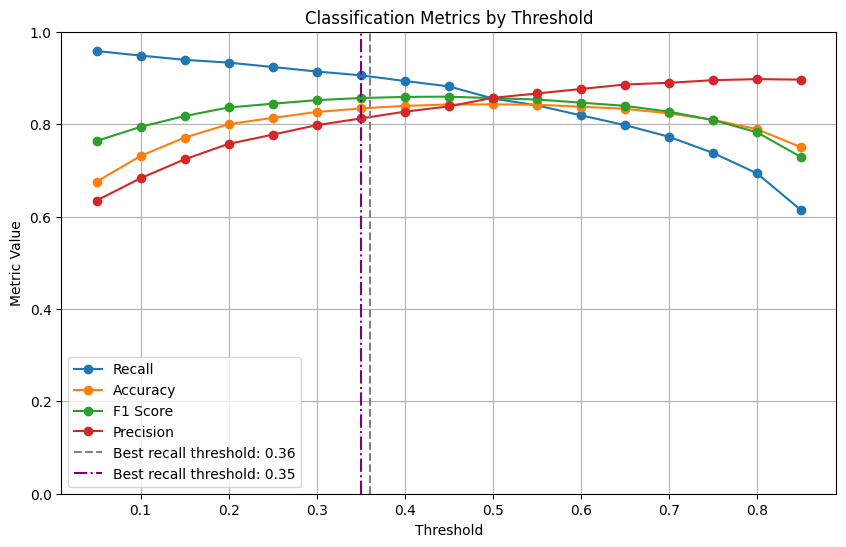

In [10]:
# Threshold range
thresholds = np.arange(0.05, 0.9, 0.05)

# Store metrics
recalls = []
accuracies = []
f1s = []
precisions = []

for t in thresholds:
    y_pred_t = (y_proba > t).astype(int)
    recalls.append(recall_score(y_test, y_pred_t))
    accuracies.append(accuracy_score(y_test, y_pred_t))
    f1s.append(f1_score(y_test, y_pred_t))
    precisions.append(precision_score(y_test, y_pred_t))

# Plot
plt.figure(figsize=(10,6))
plt.plot(thresholds, recalls, marker='o', label='Recall')
plt.plot(thresholds, accuracies, marker='o', label='Accuracy')
plt.plot(thresholds, f1s, marker='o', label='F1 Score')
plt.plot(thresholds, precisions, marker='o', label='Precision')
plt.axvline(best_thresh, color='gray', linestyle='--', label=f'Best recall threshold: {best_thresh:.2f}')
plt.axvline(0.35, color='purple', linestyle='-.', label=f'Best recall threshold: 0.35')
plt.title("Classification Metrics by Threshold")
plt.xlabel("Threshold")
plt.ylabel("Metric Value")
plt.ylim(0,1)
plt.grid(True)
plt.legend()
plt.show()

## XGBOOST EN AUTOML

In [23]:
# This one works
automl = AutoML()

# Fit AutoML
automl.fit(
    X_train=X_train_prep,
    y_train=y_train,
    time_budget=600,
    metric='accuracy',
    task='classification',
    estimator_list=['xgboost'],
    seed=3)


[flaml.automl.logger: 03-17 14:37:05] {1679} INFO - task = classification
[flaml.automl.logger: 03-17 14:37:05] {1690} INFO - Evaluation method: holdout
[flaml.automl.logger: 03-17 14:37:05] {1788} INFO - Minimizing error metric: 1-accuracy
[flaml.automl.logger: 03-17 14:37:05] {1900} INFO - List of ML learners in AutoML Run: ['xgboost']
[flaml.automl.logger: 03-17 14:37:05] {2218} INFO - iteration 0, current learner xgboost
[flaml.automl.logger: 03-17 14:37:05] {2344} INFO - Estimated sufficient time budget=1696s. Estimated necessary time budget=2s.
[flaml.automl.logger: 03-17 14:37:05] {2391} INFO -  at 1.3s,	estimator xgboost's best error=0.3813,	best estimator xgboost's best error=0.3813
[flaml.automl.logger: 03-17 14:37:05] {2218} INFO - iteration 1, current learner xgboost
[flaml.automl.logger: 03-17 14:37:05] {2391} INFO -  at 1.5s,	estimator xgboost's best error=0.3379,	best estimator xgboost's best error=0.3379
[flaml.automl.logger: 03-17 14:37:05] {2218} INFO - iteration 2, c

In [24]:
# Predict probabilities
y_proba = automl.predict_proba(X_test_prep)[:,1]  # probability of class 1

# Threshold tuning to maximize recall
thresholds = np.arange(0.1, 0.9, 0.05)
best_thresh = 0.5
best_recall = 0

for t in thresholds:
    y_pred_t = (y_proba > t).astype(int)
    r = recall_score(y_test, y_pred_t)
    if r > best_recall:
        best_recall = r
        best_thresh = t

# 10️⃣ Final predictions
y_pred = (y_proba > best_thresh).astype(int)

# 11️⃣ Print results
print(f"Best threshold for recall: {best_thresh}")
print(f"Recall at threshold {best_thresh}: {best_recall}")
print("Best estimator:", automl.best_estimator)
print("Best hyperparameters:", automl.best_config)
best_acc = 1 - automl.best_loss
print("Best accuracy:", best_acc)

Best threshold for recall: 0.1
Recall at threshold 0.1: 0.9781655034895314
Best estimator: xgboost
Best hyperparameters: {'n_estimators': 649, 'max_leaves': 3134, 'min_child_weight': 0.005078776753417549, 'learning_rate': 0.2984863090736114, 'subsample': 0.9050798835279198, 'colsample_bylevel': 0.8430671471291175, 'colsample_bytree': 0.7445745531091897, 'reg_alpha': 0.0009765625, 'reg_lambda': 913.7965894584207}
Best accuracy: 0.8321253214870236


In [7]:
y_proba = automl.predict_proba(X_test_prep)[:, 1]
thresholds = np.arange(0.0, 1.0, 0.01)
best_thresh = next(t for t in thresholds if recall_score(y_test, (y_proba > t).astype(int)) <= 0.90)
print(best_thresh)

0.41000000000000003


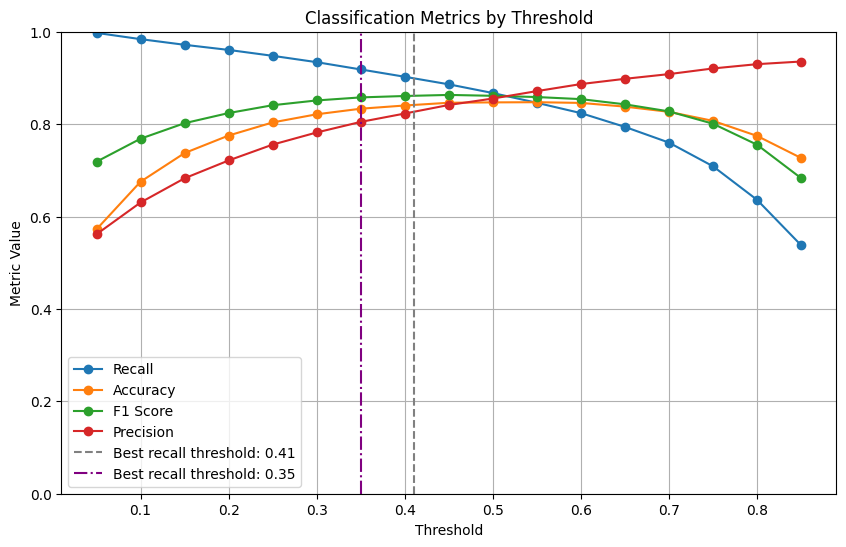

In [8]:
# Threshold range
thresholds = np.arange(0.05, 0.9, 0.05)

# Store metrics
recalls = []
accuracies = []
f1s = []
precisions = []

for t in thresholds:
    y_pred_t = (y_proba > t).astype(int)
    recalls.append(recall_score(y_test, y_pred_t))
    accuracies.append(accuracy_score(y_test, y_pred_t))
    f1s.append(f1_score(y_test, y_pred_t))
    precisions.append(precision_score(y_test, y_pred_t))

# Plot
plt.figure(figsize=(10,6))
plt.plot(thresholds, recalls, marker='o', label='Recall')
plt.plot(thresholds, accuracies, marker='o', label='Accuracy')
plt.plot(thresholds, f1s, marker='o', label='F1 Score')
plt.plot(thresholds, precisions, marker='o', label='Precision')
plt.axvline(best_thresh, color='gray', linestyle='--', label=f'Best recall threshold: {best_thresh:.2f}')
plt.axvline(0.35, color='purple', linestyle='-.', label=f'Best recall threshold: 0.35')
plt.title("Classification Metrics by Threshold")
plt.xlabel("Threshold")
plt.ylabel("Metric Value")
plt.ylim(0,1)
plt.grid(True)
plt.legend()
plt.show()

## test modele final

#### Test sans seed dans AutoML

In [20]:
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

model = XGBClassifier(objective="binary:logistic",
                          eval_metric="logloss",
                          # Hyper parameters post-tuning with Flaml
                          n_estimators=94,
                          max_leaves=955,
                          min_child_weight=0.2856018489794018,
                          learning_rate=0.044016763045230924,
                          subsample=0.8877605142833445,
                          colsample_bylevel=0.5118778106247605,
                          colsample_bytree=0.728602379406978,
                          reg_alpha=0.042224950881391936,
                          reg_lambda=0.5903340912158315)

cross_val_score(model, X_train_prep, y_train, cv=5, scoring='recall').mean()

0.8225954611033085

#### Test avec seed fixé  = 3

In [12]:
from sklearn.ensemble import RandomForestClassifier


model = RandomForestClassifier(
    n_estimators=125,
    max_features=0.28106927285321465,
    max_leaf_nodes=3448,  # ⚠️ max_leaves → max_leaf_nodes en sklearn
    criterion='gini',
    n_jobs=-1,
    random_state=3
)


cross_val_score(model, X_train_prep, y_train, cv=5, scoring='recall').mean()


0.86641638531072

#### Modèle de base finetuné via randomizedSearch

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

model = XGBClassifier(objective="binary:logistic",
                          eval_metric="logloss",
                          random_state=3,
                          # Hyper parameters with finetuning
                          colsample_bytree=0.836965827544817,
                          gamma=0.023225206359998862,
                          learning_rate=0.061721159481070736,
                          max_depth=7,
                          n_estimators=428,
                          subsample=0.6260206371941118)

cross_val_score(model, X_train_prep, y_train, cv=5, scoring='recall').mean()

0.8646664373748878

In [10]:
# Predict probabilities
model.fit(X_train_prep, y_train)
y_proba = model.predict_proba(X_test_prep)[:,1]  # probability of class 1

# Threshold tuning to maximize recall
thresholds = np.arange(0.1, 0.9, 0.05)
best_thresh = 0.5
best_recall = 0

for t in thresholds:
    y_pred_t = (y_proba > t).astype(int)
    r = recall_score(y_test, y_pred_t)
    if r > best_recall:
        best_recall = r
        best_thresh = t

# 10️⃣ Final predictions
y_pred = (y_proba > best_thresh).astype(int)

# 11️⃣ Print results
print(f"Best threshold for recall: {best_thresh}")
print(f"Recall at threshold {best_thresh}: {best_recall}")

Best threshold for recall: 0.1
Recall at threshold 0.1: 0.9783368273934312


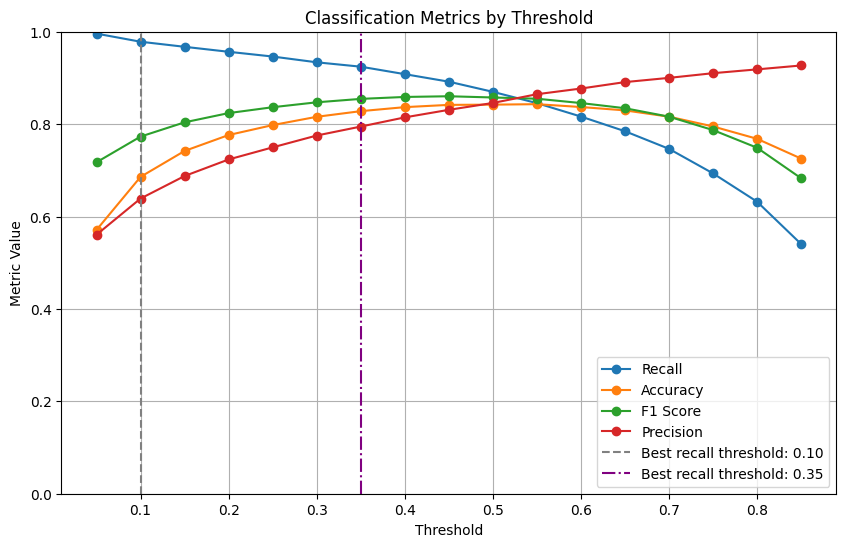

In [11]:
# Threshold range
thresholds = np.arange(0.05, 0.9, 0.05)

# Store metrics
recalls = []
accuracies = []
f1s = []
precisions = []

for t in thresholds:
    y_pred_t = (y_proba > t).astype(int)
    recalls.append(recall_score(y_test, y_pred_t))
    accuracies.append(accuracy_score(y_test, y_pred_t))
    f1s.append(f1_score(y_test, y_pred_t))
    precisions.append(precision_score(y_test, y_pred_t))

# Plot
plt.figure(figsize=(10,6))
plt.plot(thresholds, recalls, marker='o', label='Recall')
plt.plot(thresholds, accuracies, marker='o', label='Accuracy')
plt.plot(thresholds, f1s, marker='o', label='F1 Score')
plt.plot(thresholds, precisions, marker='o', label='Precision')
plt.axvline(best_thresh, color='gray', linestyle='--', label=f'Best recall threshold: {best_thresh:.2f}')
plt.axvline(0.35, color='purple', linestyle='-.', label=f'Best recall threshold: 0.35')
plt.title("Classification Metrics by Threshold")
plt.xlabel("Threshold")
plt.ylabel("Metric Value")
plt.ylim(0,1)
plt.grid(True)
plt.legend()
plt.show()

### Comparaison Classif Report RF & XGB

In [13]:
from sklearn.metrics import classification_report

def report_with_threshold(model, X, y, threshold=0.35):
    y_proba = model.predict_proba(X)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)
    print(classification_report(y, y_pred))

## Model xgb
model_xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=3,
    colsample_bytree=0.836965827544817,
    gamma=0.023225206359998862,
    learning_rate=0.061721159481070736,
    max_depth=7,
    n_estimators=428,
    subsample=0.6260206371941118
)
model_xgb.fit(X_train_prep, y_train)

## Model rf
model_rf = RandomForestClassifier(
    n_estimators=125,
    max_features=0.28106927285321465,
    max_leaf_nodes=3448,  # ⚠️ max_leaves → max_leaf_nodes en sklearn
    criterion='gini',
    n_jobs=-1,
    random_state=3
)
model_rf.fit(X_train_prep, y_train)

report_with_threshold(model_xgb, X_test_prep, y_test)
report_with_threshold(model_rf, X_test_prep, y_test)

              precision    recall  f1-score   support

           0       0.89      0.73      0.80      8304
           1       0.80      0.92      0.86     10017

    accuracy                           0.83     18321
   macro avg       0.84      0.82      0.83     18321
weighted avg       0.84      0.83      0.83     18321

              precision    recall  f1-score   support

           0       0.89      0.71      0.79      8304
           1       0.79      0.92      0.85     10017

    accuracy                           0.83     18321
   macro avg       0.84      0.82      0.82     18321
weighted avg       0.84      0.83      0.83     18321

